<a href="https://colab.research.google.com/github/massengineer/FYP-ML-Bird-Scarer/blob/main/FYP_YOLO_Second_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Mar  2 23:09:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

##Install YOLOv8

In [3]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo checks

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.8/112.6 GB disk)

OS                     Linux-6.6.113+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.12
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   43.8/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.10.0+cu128>=1.8.0
torch                  ✅ 2.10.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32

##Train YOLOv8 Model on Custom Dataset

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="B4RI3dtoSOywLRiiiPYF")
project = rf.workspace("louiss-workspace-dvwey").project("fyp-intelligent-bird-scarer-2")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [5]:
!yolo detect train data=/content/FYP-Intelligent-Bird-Scarer-2-1/data.yaml model=yolov8n.pt epochs=200 imgsz=640

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FYP-Intelligent-Bird-Scarer-2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [6]:
!yolo detect val model=/content/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1869.5±437.2 MB/s, size: 100.0 KB)
val: Scanning /content/FYP-Intelligent-Bird-Scarer-2-1/valid/labels.cache... 76 images, 34 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 10.3Mit/s 0.0s
val: /content/FYP-Intelligent-Bird-Scarer-2-1/valid/images/31528438686916f2_jpg.rf.f39a3f5ecd89df7919c5beab5a230ac9.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.1it/s 2.3s
                   all         76        177      0.895      0.529      0.644      0.503
                  duck         29        159      0.774      0.327      0.485      0.308
                 raven          4          7      0.936      0.714      0.814      0.651
               sparrow          9         11      0.976   

In [8]:
!yolo detect predict model=/content/runs/detect/train/weights/best.pt conf=0.5 source={dataset.location}/test/images

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

image 1/38 /content/FYP-Intelligent-Bird-Scarer-2-1/test/images/008386b8a8f54777_jpg.rf.0d2f54a95765c1a5c218452e8a26f0b9.jpg: 640x640 1 sparrow, 7.9ms
image 2/38 /content/FYP-Intelligent-Bird-Scarer-2-1/test/images/03d5d8ac19148343_jpg.rf.b8260626f0ae7f97ab64234e173e2a00.jpg: 640x640 (no detections), 6.2ms
image 3/38 /content/FYP-Intelligent-Bird-Scarer-2-1/test/images/0419027d71b0510f_jpg.rf.67ad0cef665fd1c4f2743860ad1f559e.jpg: 640x640 (no detections), 6.1ms
image 4/38 /content/FYP-Intelligent-Bird-Scarer-2-1/test/images/09bca3a5de748416_jpg.rf.c6b7f1d0b369e17ecf8cc0decc5df28c.jpg: 640x640 2 ducks, 6.1ms
image 5/38 /content/FYP-Intelligent-Bird-Scarer-2-1/test/images/0aed0e968064127a_jpg.rf.5ac71c2839cc440c210f768639167578.jpg: 640x640 5 ducks, 6.2ms
image 6/38 /content/FYP-Intelligent-Bird-Scarer-2-1/test/images/0b532c206

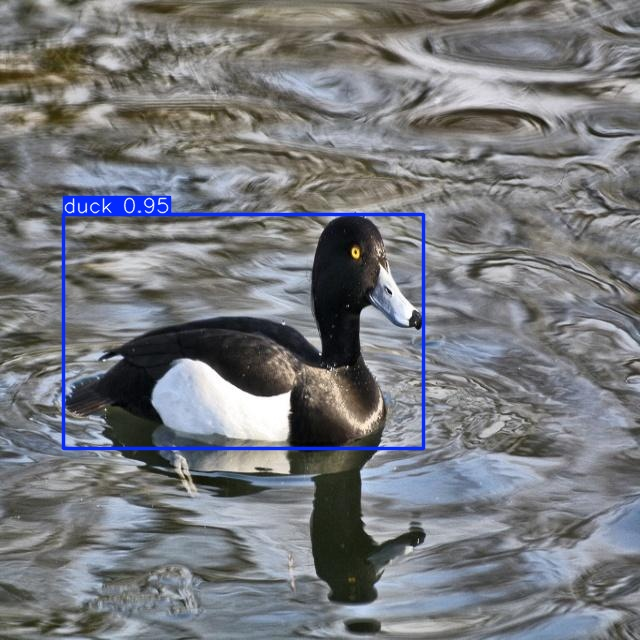

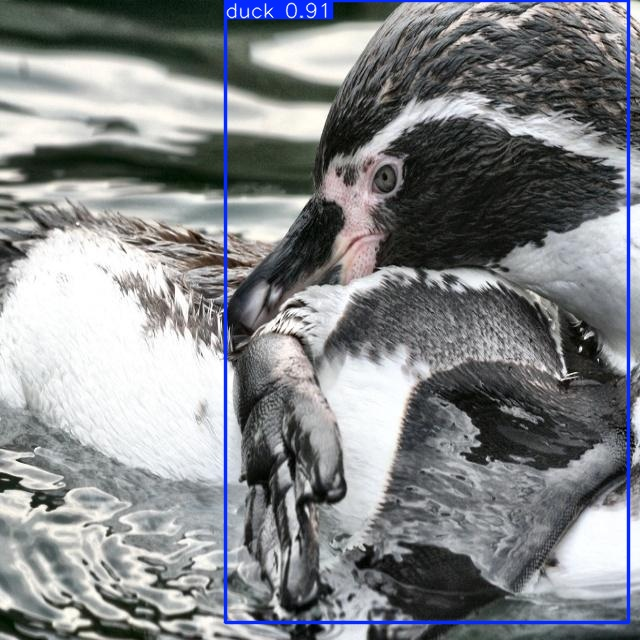

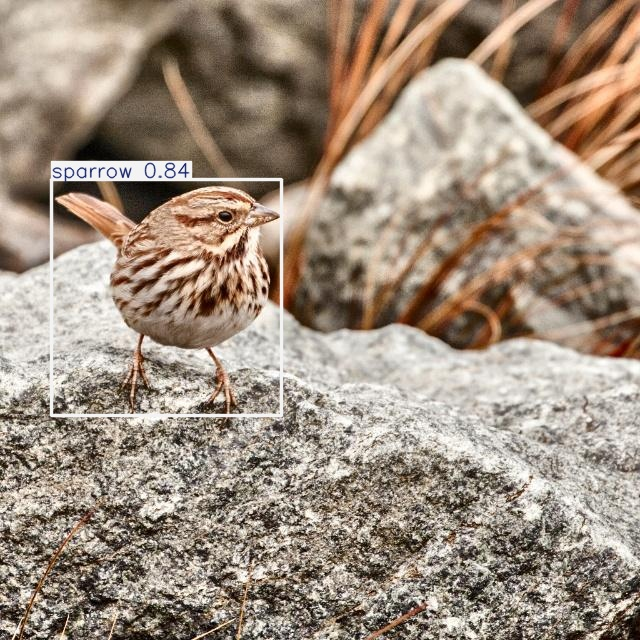

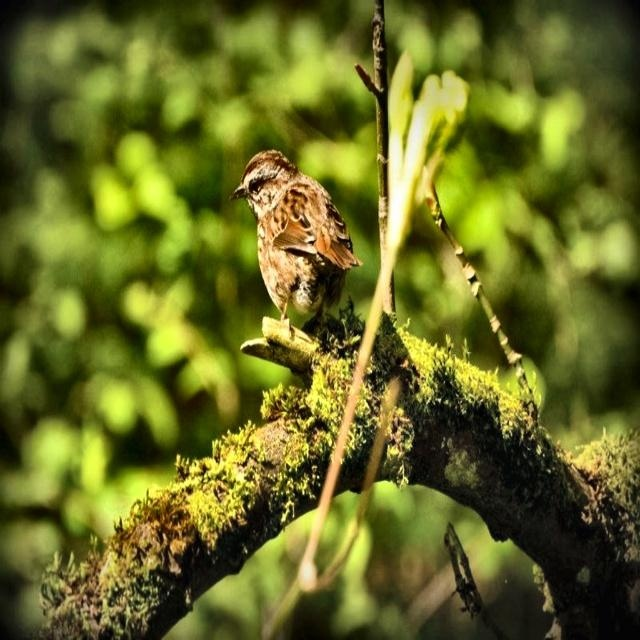

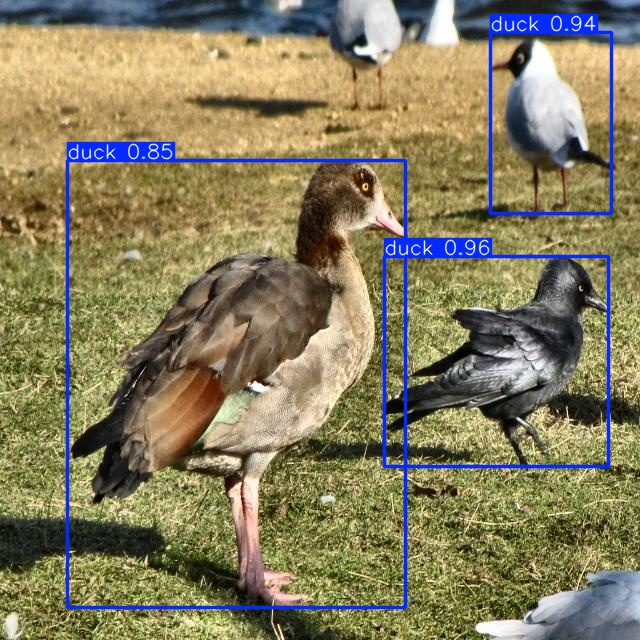

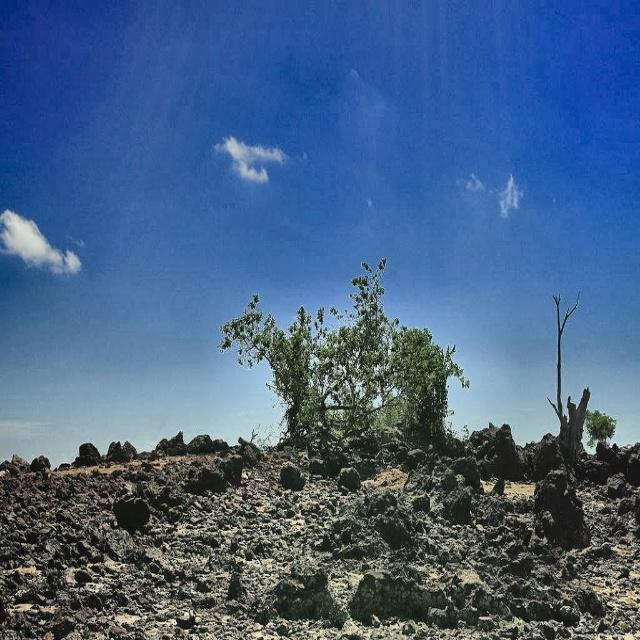

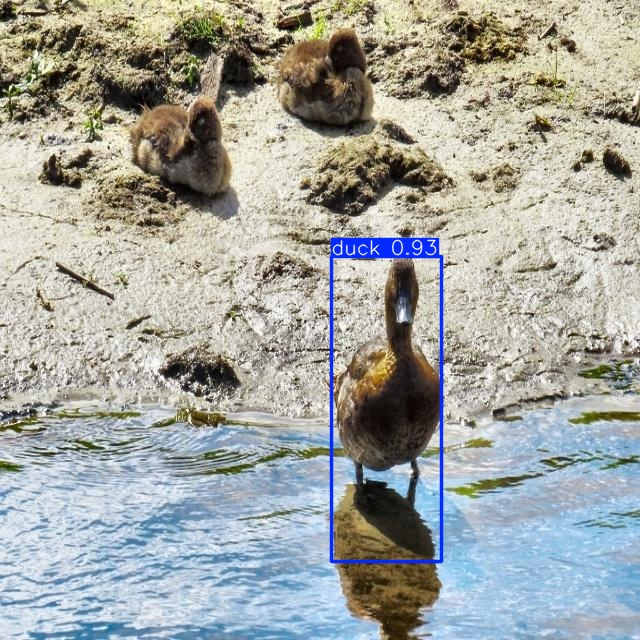

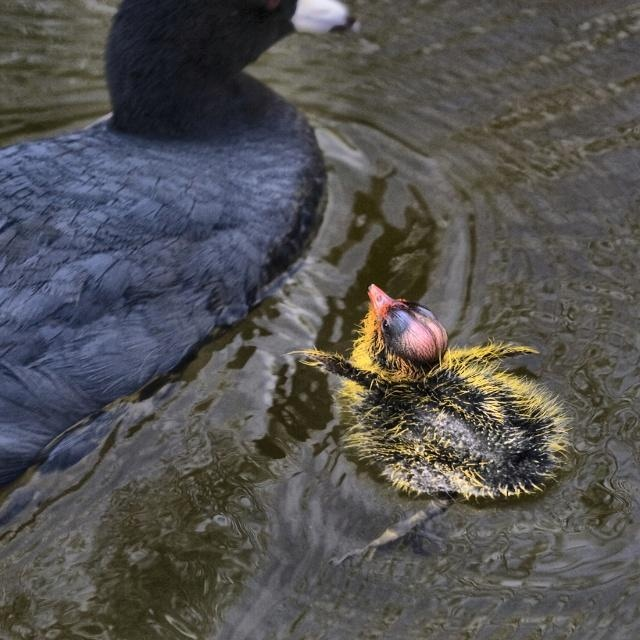

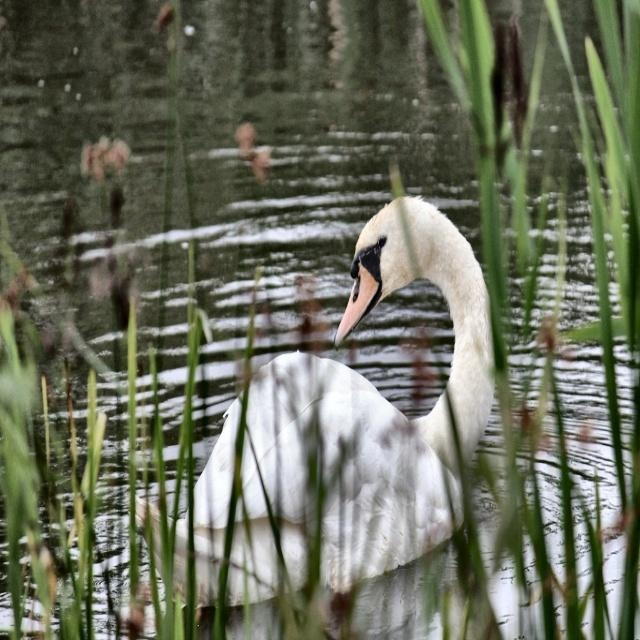

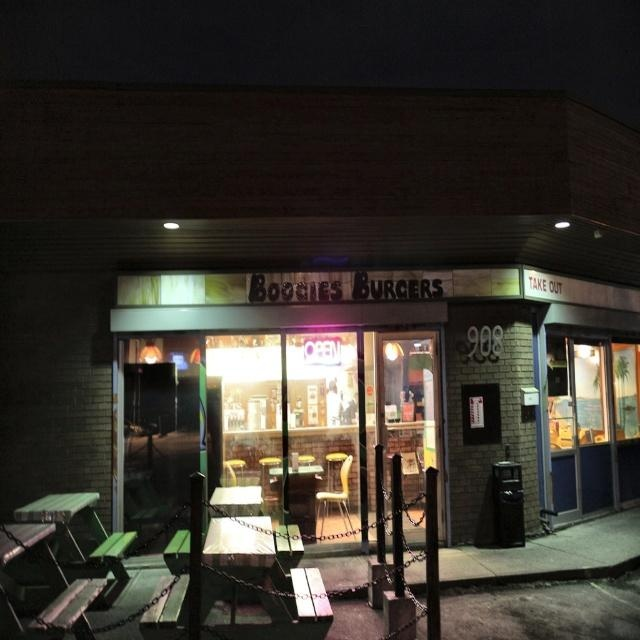

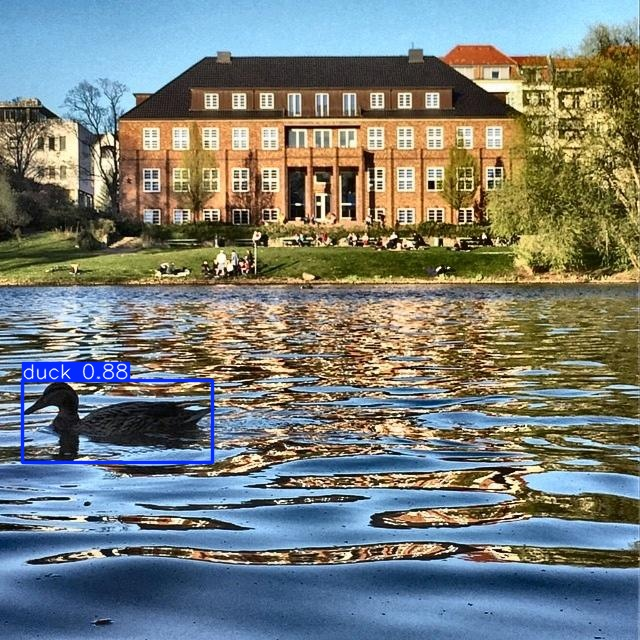

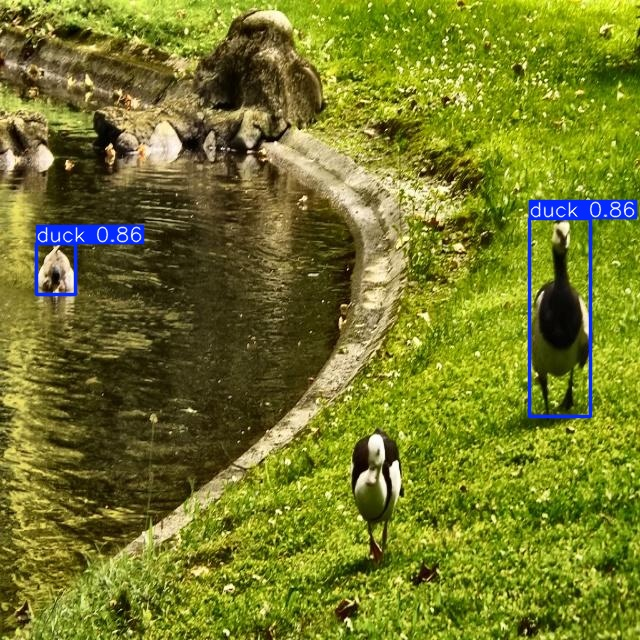

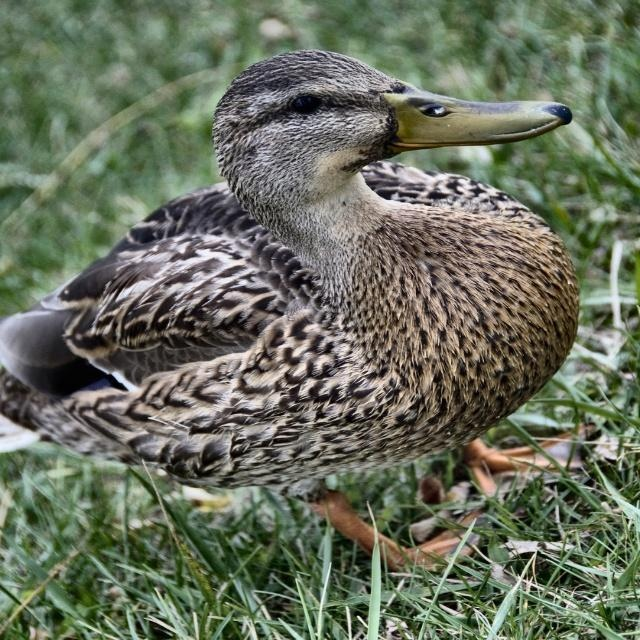

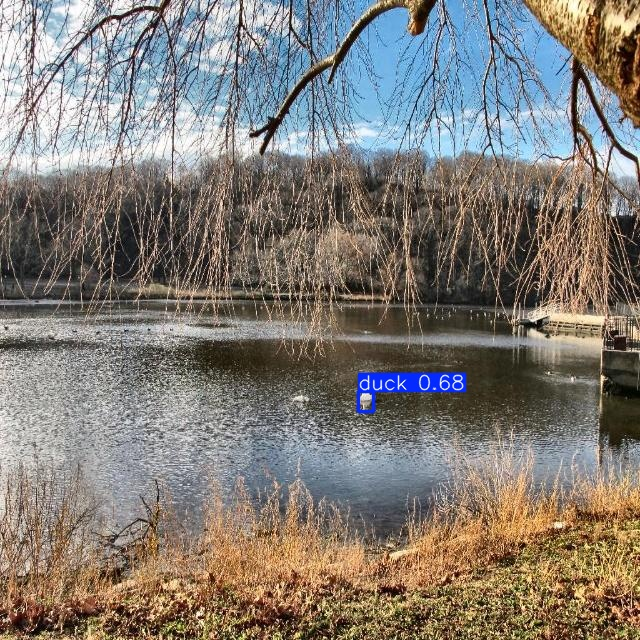

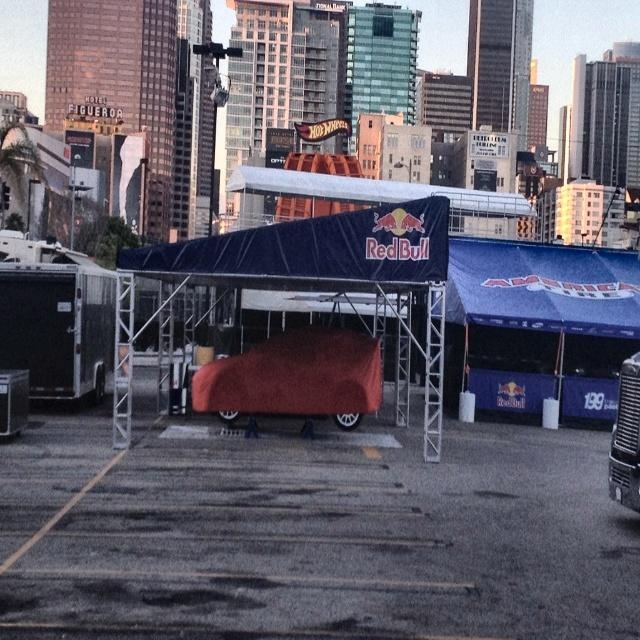

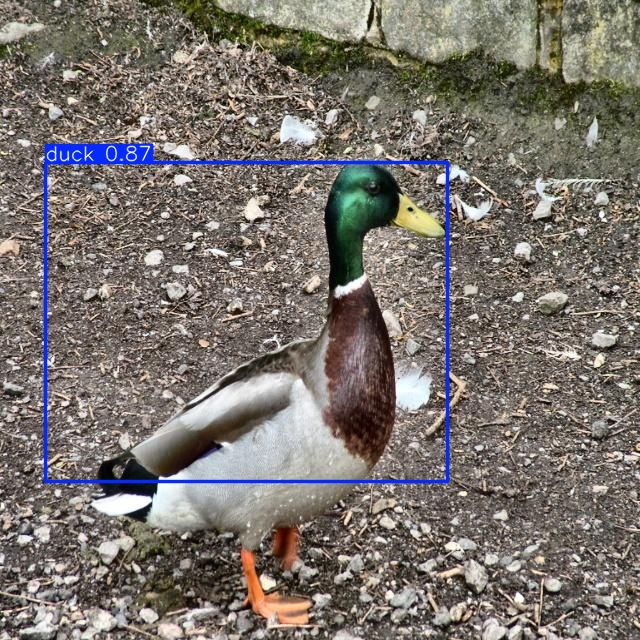

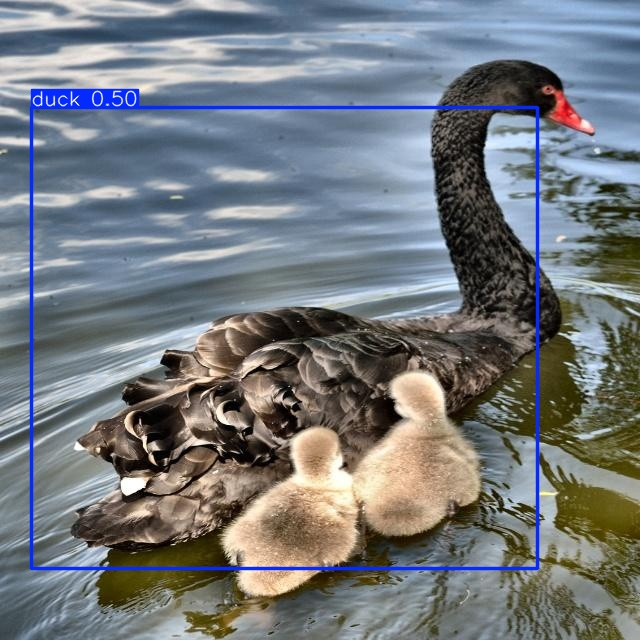

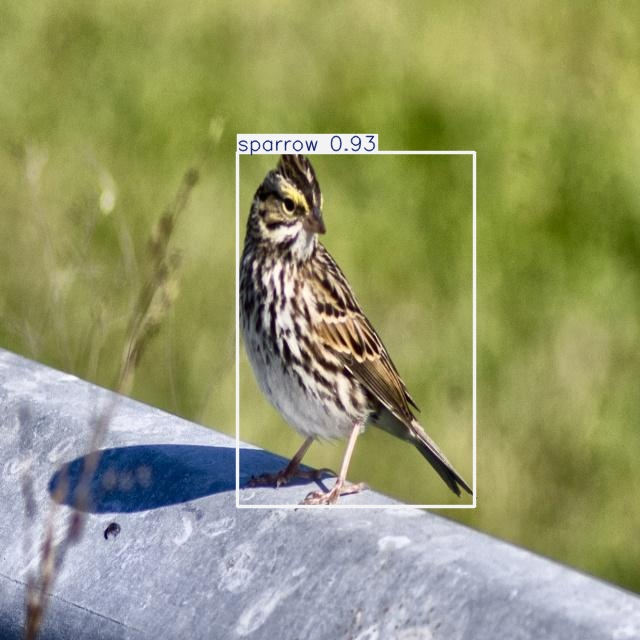

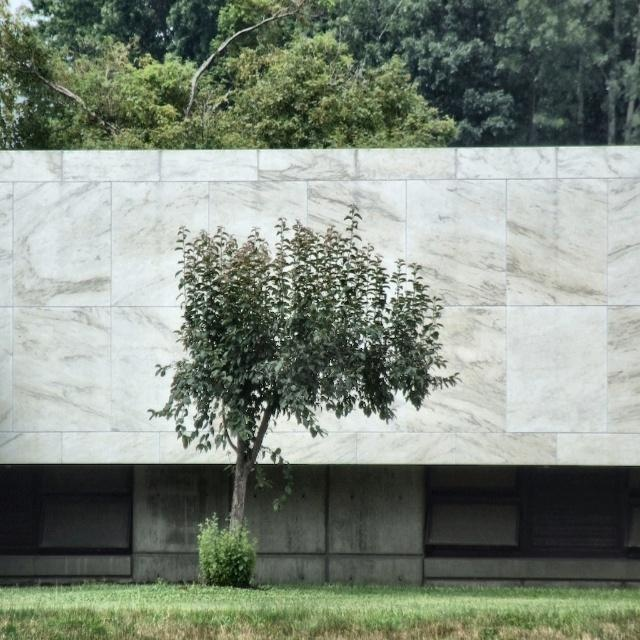

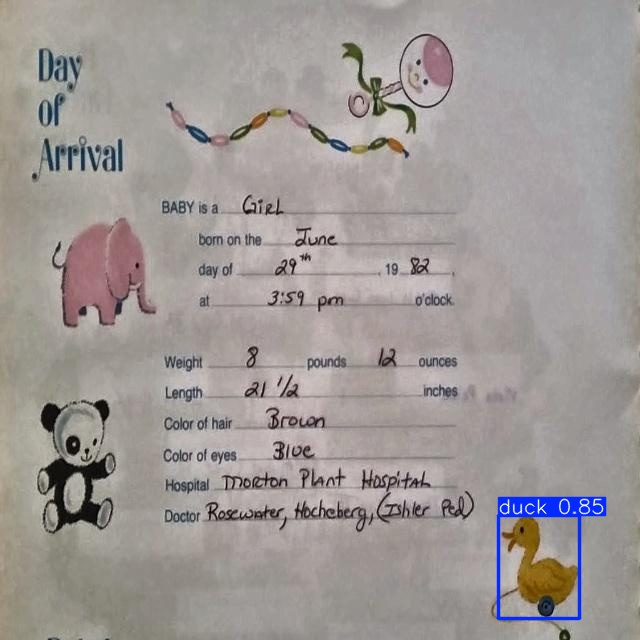

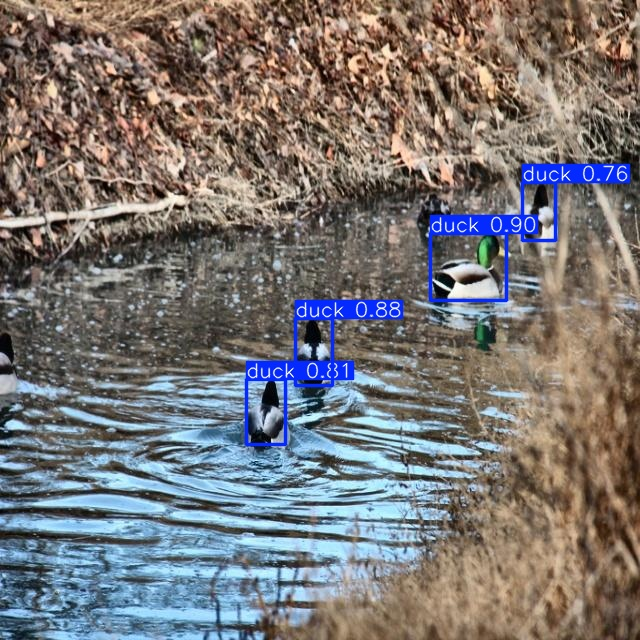

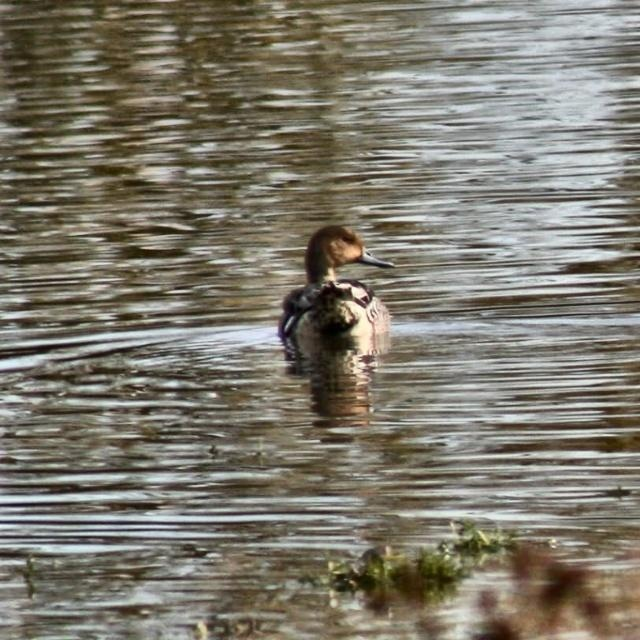

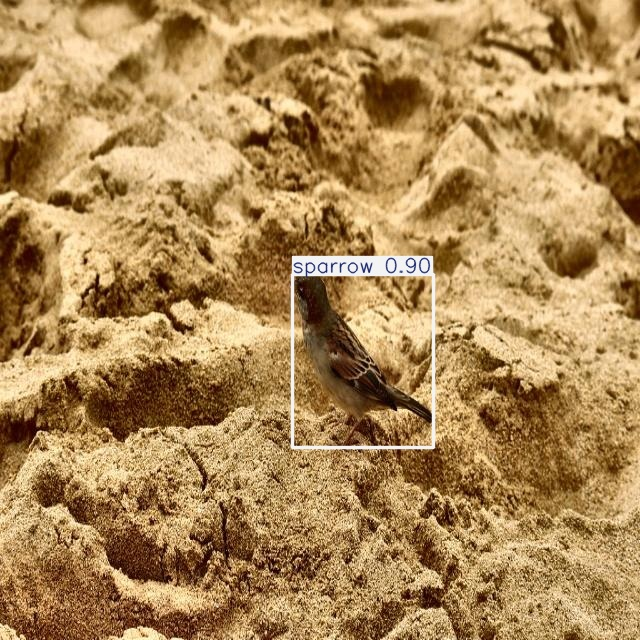

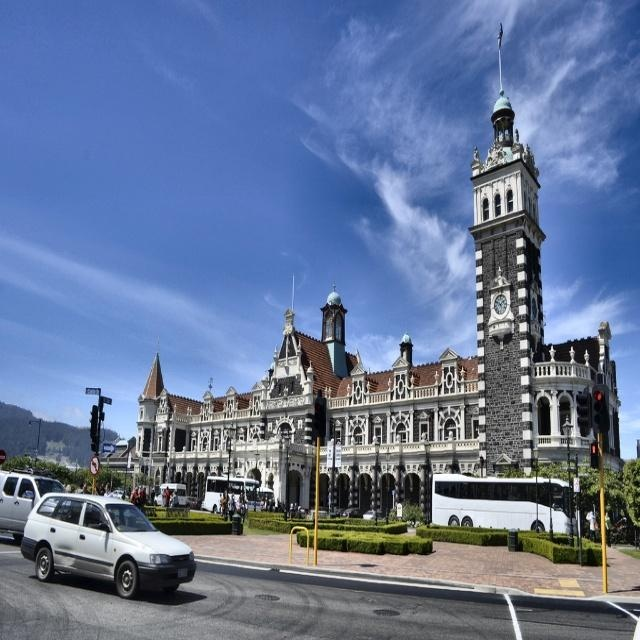

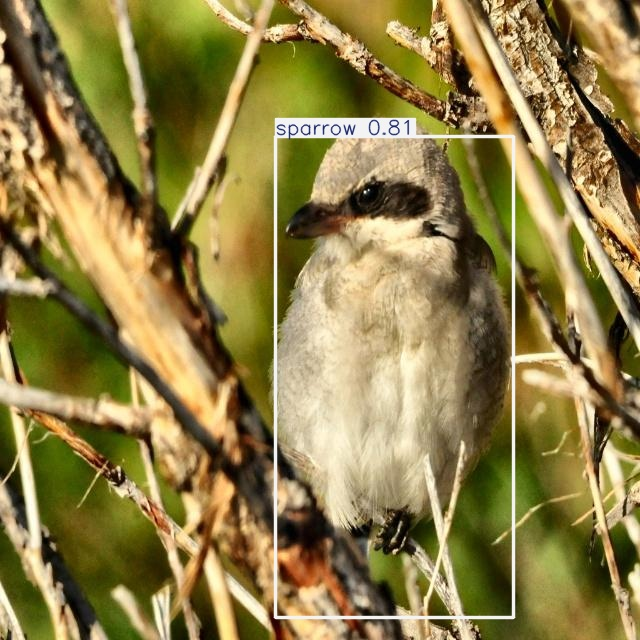

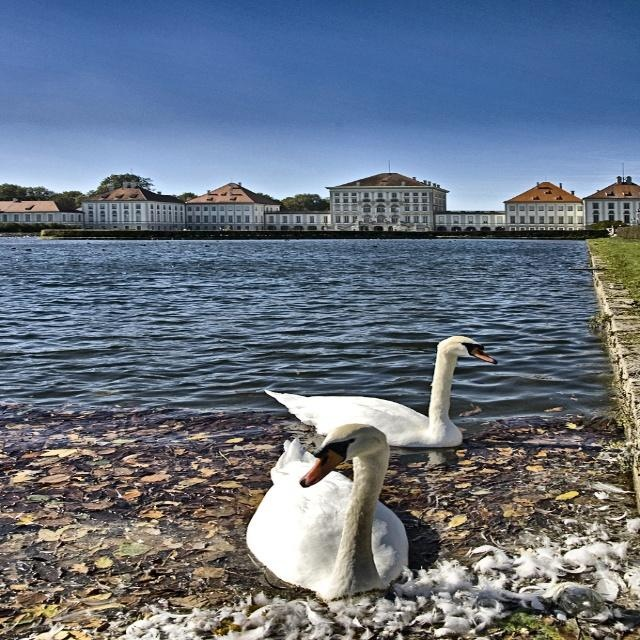

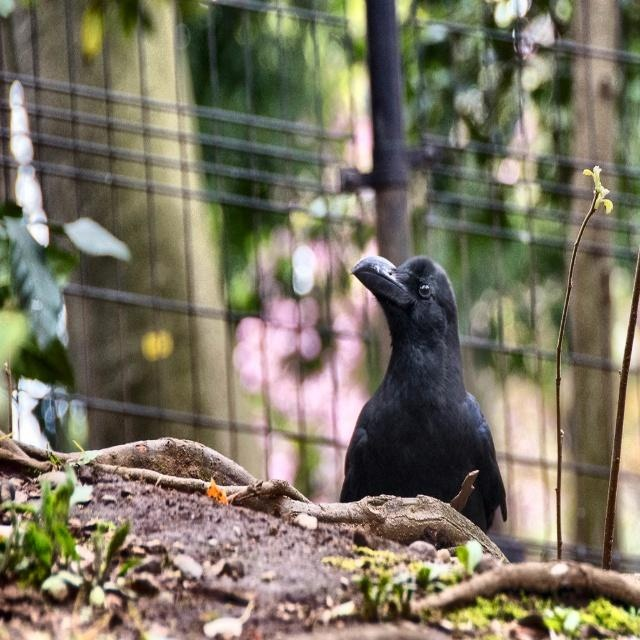

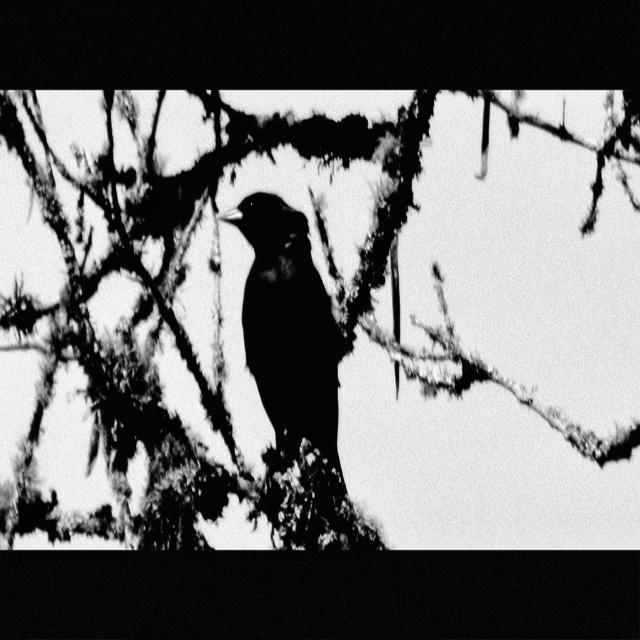

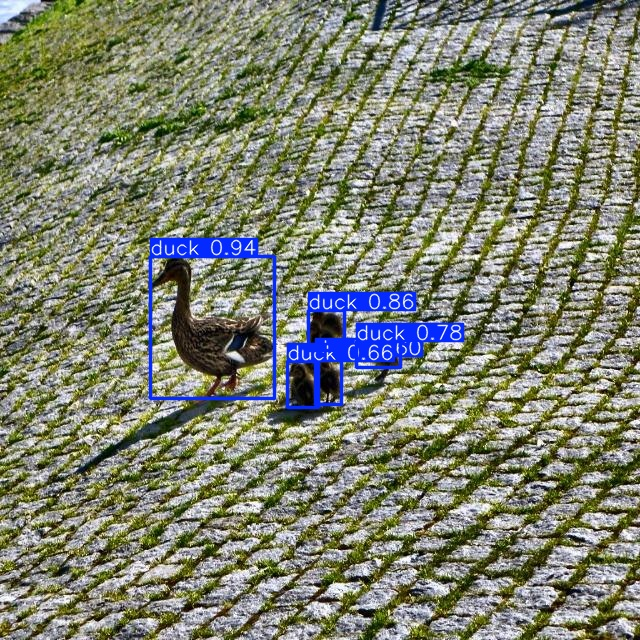

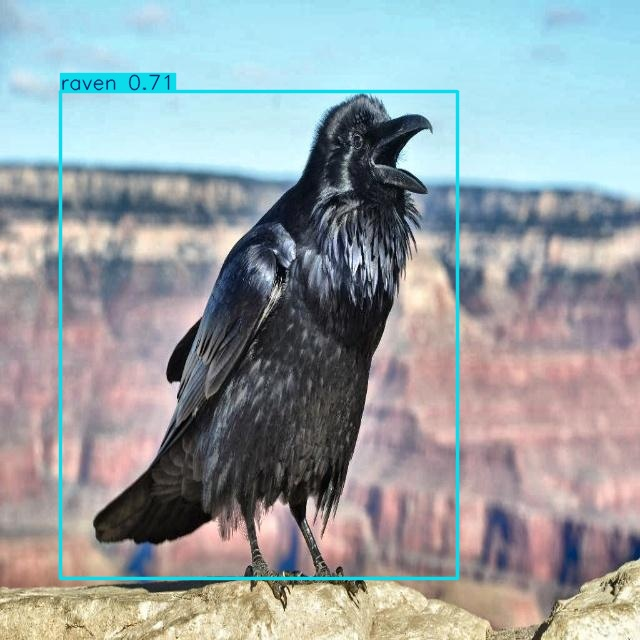

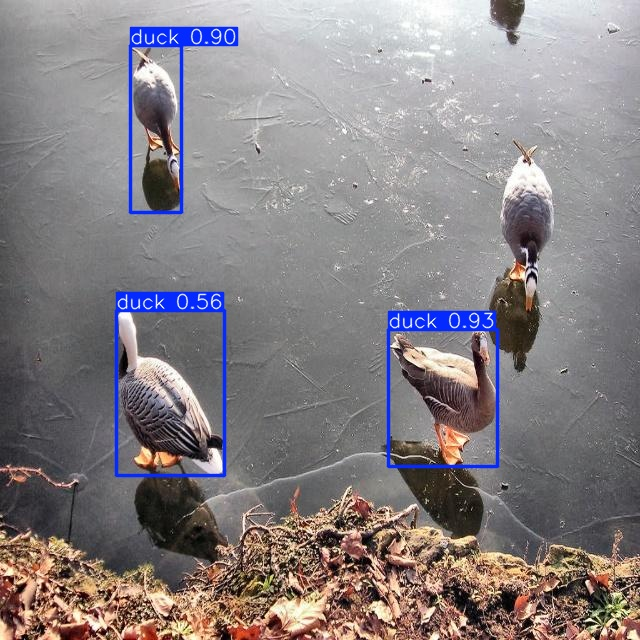

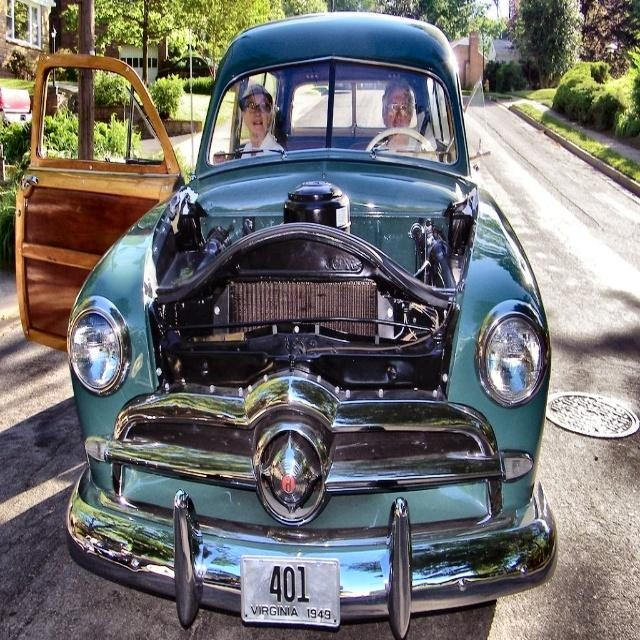

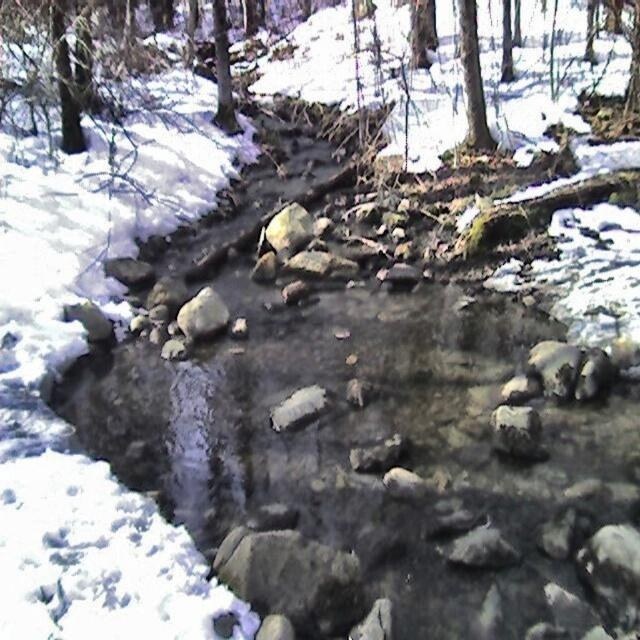

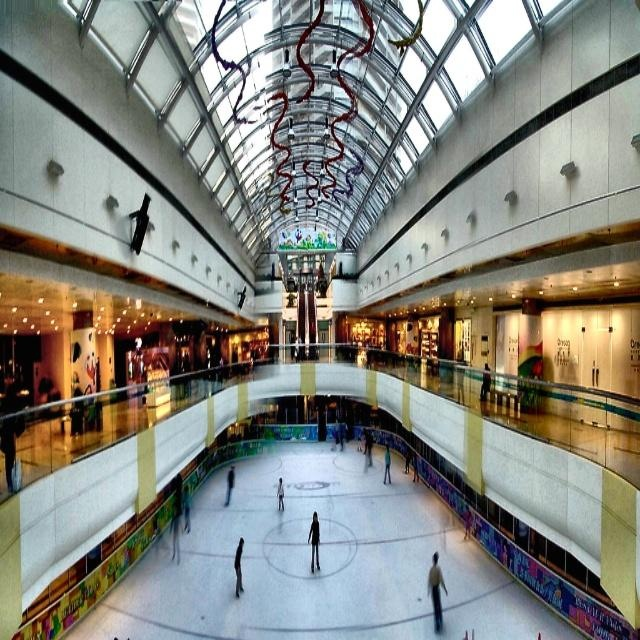

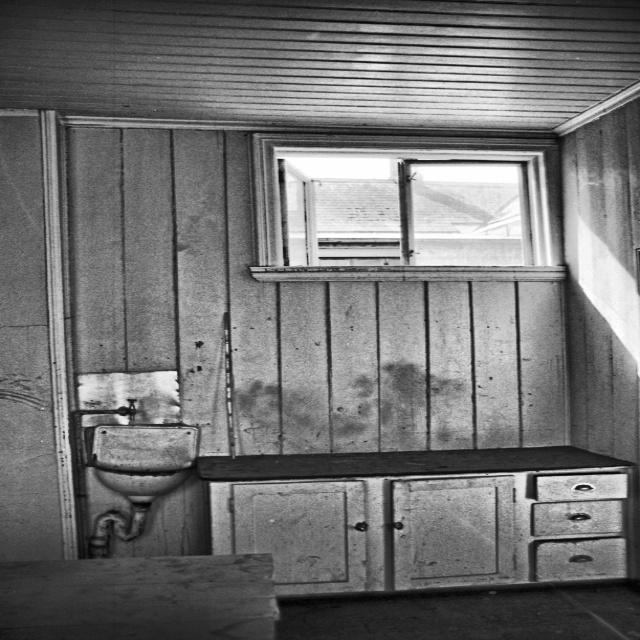

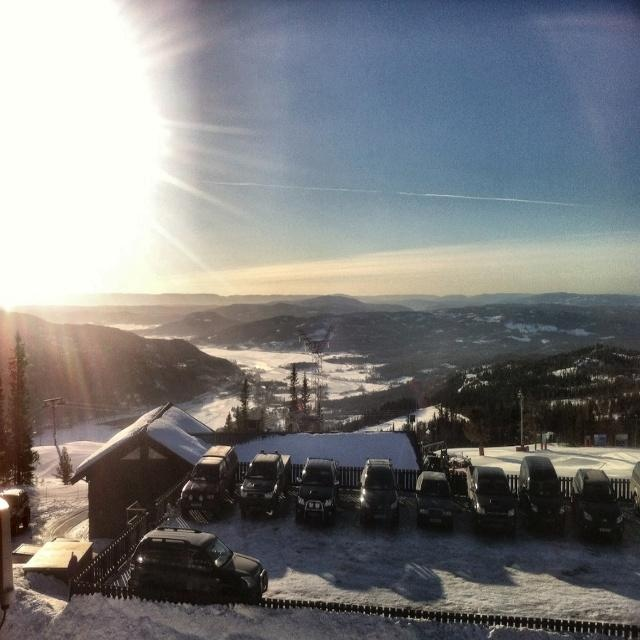

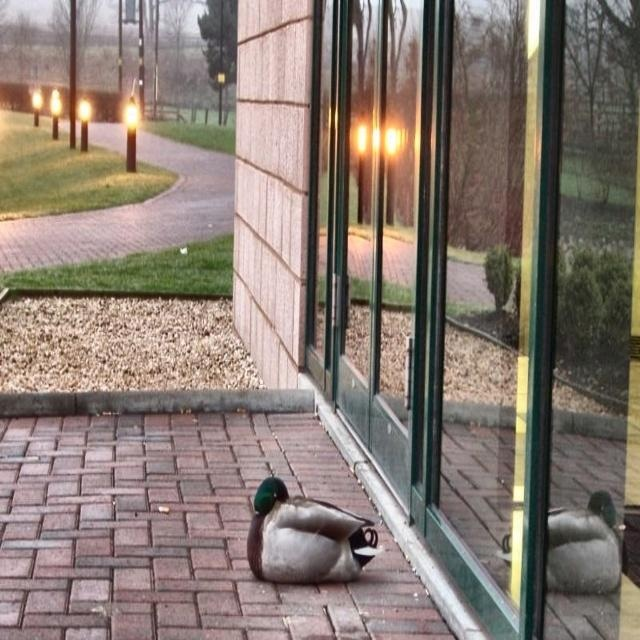

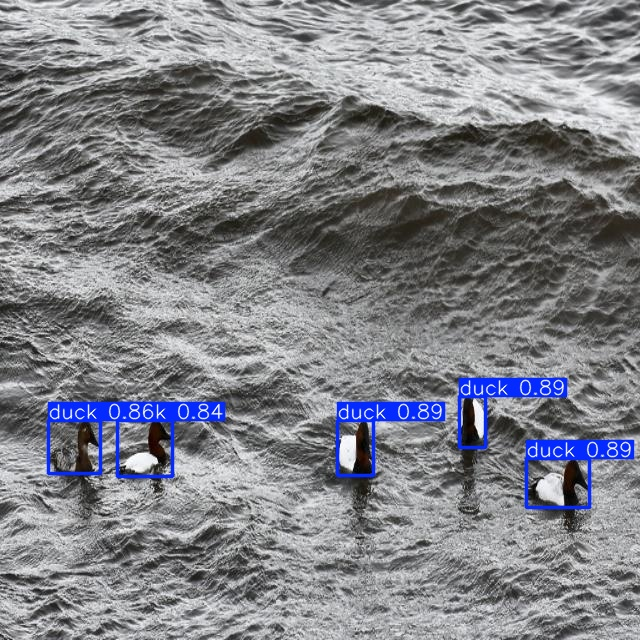

In [12]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict2/*.jpg'):
  display(Image(filename=image_path, height=600))
  print('\n')